<a href="https://colab.research.google.com/github/MatteoBaraldi/Machine-Learning-for-Bioengineering/blob/main/MOD-2/01_clustering_exercises/exercise_kmeans_hierarchical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practice: K-means and Hierarchical Clustering

## Learning objectives

By the end of this practice you will be able to:

- apply K-means and hierarchical clustering
- compare clustering results using visual inspection and quantitative metrics
- discuss when centroid-based and hierarchical approaches are more appropriate

## 1. Imports

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import dendrogram, linkage

np.random.seed(42)

## 2. Create a synthetic dataset

The dataset below includes four subpopulations that are not well represented by spherical clusters.

In [50]:
# ---- Cluster 1 (compact) ----
mean1 = [2, 2, 2]
cov1 = [[0.2, 0.05, 0.0],
        [0.05, 0.2, 0.05],
        [0.0, 0.05, 0.2]]
X1 = np.random.multivariate_normal(mean1, cov1, 120)

# ---- Cluster 2 (elongated) ----
mean2 = [6, 5, 7]
cov2 = [[2.0, 1.5, 1.0],
        [1.5, 2.0, 1.2],
        [1.0, 1.2, 1.5]]
X2 = np.random.multivariate_normal(mean2, cov2, 180)

# ---- Cluster 3 (overlapping, high variance) ----
mean3 = [4, 8, 5]
cov3 = [[1.5, -0.8, 0.3],
        [-0.8, 2.0, -0.5],
        [0.3, -0.5, 1.5]]
X3 = np.random.multivariate_normal(mean3, cov3, 150)

# ---- Cluster 4 (curved trajectory) ----
t = np.linspace(0, 1, 160)
x = 3 + 5*t
y = 3 + 4*(t**2)
z = 2 + 3*np.sin(2*np.pi*t)
curve = np.vstack([x, y, z]).T
noise = np.random.normal(scale=0.3, size=curve.shape)
X4 = curve + noise

# ---- Combine dataset ----
X = np.vstack([X1, X2, X3, X4])
y_true = np.array(
    [0]*len(X1) +
    [1]*len(X2) +
    [2]*len(X3) +
    [3]*len(X4)
)

feature_names = [
    "Biomarker 1",
    "Biomarker 2",
    "Biomarker 3",
]

df = pd.DataFrame(X, columns=feature_names)
df["true_group"] = y_true
df.head()

,Biomarker 1,Biomarker 2,Biomarker 3,true_group
0,1.943501,1.652579,2.030947,0
1,1.487645,1.499197,1.635737,0
2,1.747449,1.538362,1.262081,0
3,1.628577,1.918802,1.921668,0
4,1.021909,2.349546,2.231973,0


## 3. Quick exploration

Make 2D plots of all the possible projections. The 4 clusters are not perfecly separated by any 2D projections. Choose the projection that better separates the clusters and use that one for the rest of the exercise (but remember that: 1) clustering works with all the features; 2) in a real case you don't know the "true" clusters).

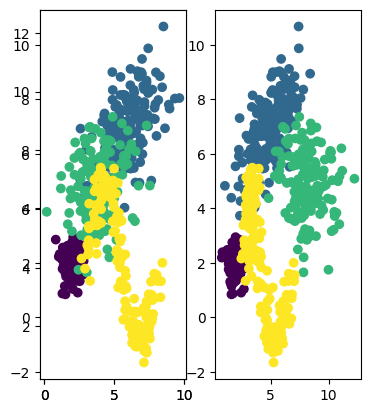

In [51]:
f = plt.figure()
for i in range(3):
    for j in range(i + 1, 3):
      ax = f.add_subplot(1, 3, i+1)
      ax.scatter(X[:,i], X[:,j], c = y_true)

## 4. Standardize the features

Normalize the features to zero mean and unitary standard deviation

In [52]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 6. K-means clustering

Try to define the optimal number of clusters using the elbow method and the silhoutte score.

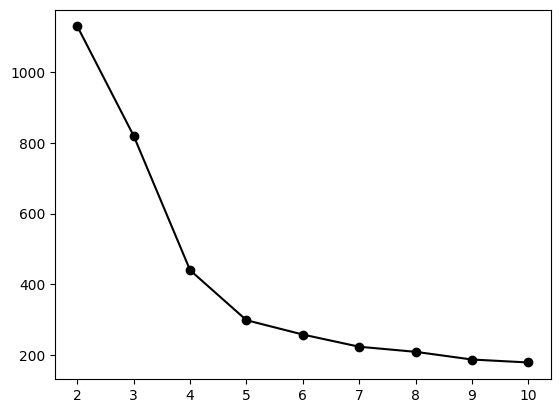

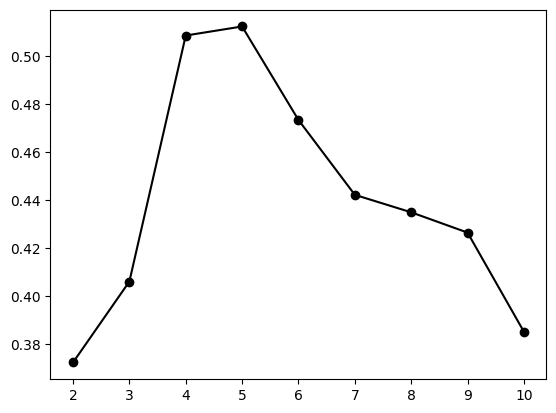

In [ ]:
Ks = range(2, 11)
sil_scores = []
inertias = []

for k in Ks:
    kmeans = KMeans(n_clusters=k, random_state=42)
    y_c = kmeans.fit_predict(X_scaled)
    sil_score = silhouette_score(X_scaled, y_c)
    sil_scores.append(silhouette_score(X_scaled, y_c))
    inertias.append(kmeans.inertia_)

f = plt.figure()
ax = f.add_subplot(1,1,1)
ax.plot(Ks, inertias, 'o-k')

f = plt.figure()
ax = f.add_subplot(1,1,1)
ax.plot(Ks, sil_scores, 'o-k')

* Perform clustering with Kmeans using 4 clusters (even if that's probably not what you should do based on the plots before)
* Create a scatter plot in 2D over the features selected before with samples coloured as the Kmeans labels

## 7. Hierarchical clustering

* Perform hierarchical clustering using the class AgglomerativeClustering
* Test the different linkage methods: ward, complete, average, and single
* For each method compute the silhoutte score

In [55]:
linkages = ["ward", "complete", "average", "single"]
score = {}

for i, link in enumerate(linkages):
    hier = AgglomerativeClustering(linkage=link, n_clusters = 4)
    y_h = hier.fit_predict(X_scaled)
    score[link] = silhouette_score(X_scaled, y_h)
print(score)

{'ward': np.float64(0.49480787266984816), 'complete': np.float64(0.45126961132927074), 'average': np.float64(0.4998173445902392), 'single': np.float64(0.0923781902552971)}


* Perform clustering using the best linkage method identified

In [58]:
km = KMeans(n_clusters=4, random_state=42)
y_c = km.fit_predict(X_scaled)
ars_km = adjusted_rand_score(y_true, y_c)
print(ars_km)

hier = AgglomerativeClustering(linkage="ward", n_clusters = 4)
y_h = hier.fit_predict(X_scaled)
ars_hier = adjusted_rand_score(y_true, y_h)
print(ars_hier)

0.5994093872474922
0.6657616498311856


## 8. Dendrogram

Use the methods linkage and dendrogram to plot the hierarchical tree connecting the samples in the dataset.

{'icoord': [[15.0, 15.0, 25.0, 25.0],
  [5.0, 5.0, 20.0, 20.0],
  [35.0, 35.0, 45.0, 45.0],
  [55.0, 55.0, 65.0, 65.0],
  [40.0, 40.0, 60.0, 60.0],
  [12.5, 12.5, 50.0, 50.0],
  [85.0, 85.0, 95.0, 95.0],
  [75.0, 75.0, 90.0, 90.0],
  [115.0, 115.0, 125.0, 125.0],
  [105.0, 105.0, 120.0, 120.0],
  [135.0, 135.0, 145.0, 145.0],
  [155.0, 155.0, 165.0, 165.0],
  [140.0, 140.0, 160.0, 160.0],
  [112.5, 112.5, 150.0, 150.0],
  [82.5, 82.5, 131.25, 131.25],
  [175.0, 175.0, 185.0, 185.0],
  [205.0, 205.0, 215.0, 215.0],
  [195.0, 195.0, 210.0, 210.0],
  [180.0, 180.0, 202.5, 202.5],
  [235.0, 235.0, 245.0, 245.0],
  [225.0, 225.0, 240.0, 240.0],
  [255.0, 255.0, 265.0, 265.0],
  [232.5, 232.5, 260.0, 260.0],
  [191.25, 191.25, 246.25, 246.25],
  [285.0, 285.0, 295.0, 295.0],
  [275.0, 275.0, 290.0, 290.0],
  [305.0, 305.0, 315.0, 315.0],
  [325.0, 325.0, 335.0, 335.0],
  [310.0, 310.0, 330.0, 330.0],
  [282.5, 282.5, 320.0, 320.0],
  [355.0, 355.0, 365.0, 365.0],
  [345.0, 345.0, 360.0, 360.

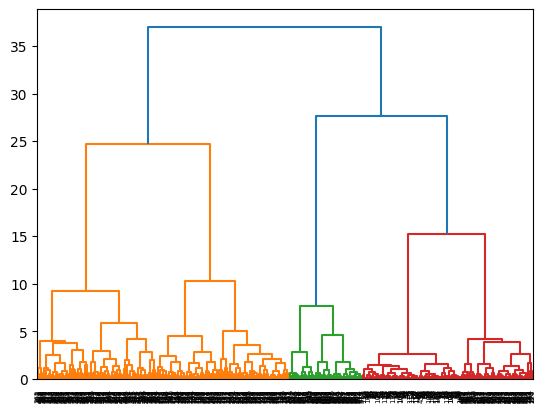

In [60]:
Z = linkage(X_scaled, method='ward')
plt.figure()
dendrogram(Z)

## 9. Compare K-means and hierarchical clustering

* Compare the two methods with respect to silhoutte score and adjusted rank index


In [63]:

k_means_silhouette = sil_scores[np.argmax(sil_scores)]
k_means_ari = ars_km

best_hier_linkage = max(score, key=score.get)
hierarchical_silhouette = score[best_hier_linkage]
hierarchical_ari = ars_hier

print(f"Silhouette Score: {k_means_silhouette:.3f}")
print(f"Adjusted Rand Index: {k_means_ari:.3f}\n")

print(f"Silhouette Score: {hierarchical_silhouette:.3f}")
print(f"Adjusted Rand Index: {hierarchical_ari:.3f}")

Silhouette Score: 0.512
Adjusted Rand Index: 0.599

Silhouette Score: 0.500
Adjusted Rand Index: 0.666


From the metrics, we can observe the following:

*   **Silhouette Score**: The silhouette score for Hierarchical Clustering with the '{best_hier_linkage}' linkage ({hierarchical_silhouette:.3f}) is slightly higher than that of K-means ({k_means_silhouette:.3f}). This suggests that the clusters formed by hierarchical clustering are slightly more dense and well-separated.

*   **Adjusted Rand Index (ARI)**: Hierarchical Clustering also shows a higher Adjusted Rand Index ({hierarchical_ari:.3f}) compared to K-means ({k_means_ari:.3f}). The ARI measures the similarity between the true labels and the clustering labels, adjusted for chance. A higher ARI indicates better agreement with the true underlying structure of the data. In this specific synthetic dataset, Hierarchical Clustering appears to capture the true groups more effectively than K-means.

**Conclusion**: Based on both the Silhouette Score and the Adjusted Rand Index, **Hierarchical Clustering with '{best_hier_linkage}' linkage performs better** than K-means for this dataset. This is likely due to the complex, non-spherical shapes of the clusters in the synthetic dataset, which hierarchical clustering is often better equipped to handle than K-means.